In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt


from ufig import rolling_window, plot_hist_errorbar, plot_hist_band, plot_ratio_band, plot_ratio_errorbar, plot_data_hist_errorbar, plot_data_ratio_errorbar, make_hist_error
from ufig.figures import SinglePlot
from NNMFit.kde_tools.kde_utilities import KDEKernel
from NNMFit.utilities import load_pickle


No cuda in path, using pykde


#### Functions to use in later loops

In [25]:
def get_keys(selection):
    # cscd_cascade
    df = pd.read_parquet(
        f"/data/ana/Diffuse/GlobalFit/NNMFit/datasets/SnowStorm_v2_cscd_{selection}_baseline/dataset_cscd_{selection}_baseline_all_keys_galactic.parquet"
    )

    # only use MuonGun Events from the df
    df = df[~np.isnan(df['cscdSBU_MuonWeight_GaisserH4a'])]

    # access relevant keys
    reco_energy = df['energy_monopod']
    reco_zenith = df['zenith_monopod']
    weights = df['muongun_conv_H4a_SIBYLL']

    return reco_energy, reco_zenith, weights


def plot_unweighted(
    selection, bins_loge, bins_cos, reco_energy, reco_zenith, weights
):
    plt.figure()
    h = plt.hist2d(
        np.log10(reco_energy),
        np.cos(reco_zenith),
        # weights=weights,
        bins=(bins_loge, bins_cos),
    )
    plt.colorbar(label=f'simulated events ({selection})')

    pc = plt.scatter(
        x=np.log10(reco_energy),
        y=np.cos(reco_zenith),
        c=weights,
        cmap="inferno",
        marker=".",
        s=100
    )
    plt.colorbar(pc, label=f"muongun weight ({selection})", extend='both')

    plt.xlabel('log10(E / GeV)')
    plt.ylabel('cos(zenith)')
    plt.savefig(
        "/home/pfuerst/public_html/galactic_wiki_resources/muongun_template/{}_unweighted_scatterplot.png"
        .format(selection)
    )
    plt.show()

In [26]:
def plot_kde_summary(
    selection, reco_energy, reco_zenith, weights, bins_e_fine, bins_cos_fine,
    rate_fine, rate_error_fine
):

    # plot rate, error, relative error in 2D in a 3 panel plot
    fig, axes = plt.subplots(ncols=3)
    ax1 = axes[0]
    ax2 = axes[1]
    ax3 = axes[2]

    # plot rate
    # ax1.set_title("Rate and Muongun Events")
    X_plot, Y_plot = np.meshgrid(bins_e_fine, bins_cos_fine)
    pm = ax1.pcolormesh(X_plot, Y_plot, rate_fine, vmin=0, cmap="Reds")
    plt.colorbar(pm, label="KDE", extend='both')

    pc = ax1.scatter(
        x=np.log10(reco_energy),
        y=np.cos(reco_zenith),
        c=weights,
        cmap="inferno",
        marker=".",
        s=20,
    )
    plt.colorbar(pc, label="event weight", extend='both')

    # plot error
    # ax2.set_title("KDE Error")
    X_plot, Y_plot = np.meshgrid(bins_e_fine, bins_cos_fine)
    pm = ax2.pcolormesh(X_plot, Y_plot, rate_error_fine, vmin=0, cmap="Reds")
    plt.colorbar(pm, label="KDE Uncertainty", extend='both')

    # plot relative error
    X_plot, Y_plot = np.meshgrid(bins_e_fine, bins_cos_fine)
    pm = ax3.pcolormesh(
        X_plot, Y_plot, rate_error_fine / rate_fine, vmin=0, cmap="Reds"
    )
    plt.colorbar(pm, label="Relative Uncertainty", extend='both')

    ax1.set_xlabel(r"log($E_{\mathrm{Monopod}}$ / GeV)")
    ax1.set_xlim(bins_e_fine[0], bins_e_fine[-1])
    ax2.set_xlabel(r"log($E_{\mathrm{Monopod}}$ / GeV)")
    ax3.set_xlabel(r"log($E_{\mathrm{Monopod}}$ / GeV)")
    ax1.set_ylabel(r"cos($\Theta_{\mathrm{Monopod}}$)")
    fig.tight_layout()
    # fig.save(
    #     f"/home/pfuerst/public_html/galactic_wiki_resources/muongun_template({selection})_kde_summary.png",
    #     format="png"
    # )
    plt.show()

In [27]:
def plot_kde_hist_2D(
    selection, reco_energy, reco_zenith, weights, bins_e, bins_cos,
    integrated_rate
):
    fig = SinglePlot(height_scale=1.2)
    fig, axes = fig.create(dpi=200)
    ax1 = axes
    X_plot, Y_plot = np.meshgrid(bins_e, bins_cos)
    pm = ax1.pcolormesh(X_plot, Y_plot, integrated_rate.T, vmin=0, cmap="Reds")
    plt.colorbar(pm, label="KDE", extend='both')

    pc = ax1.scatter(
        x=np.log10(reco_energy),
        y=np.cos(reco_zenith),
        c=weights,
        cmap="inferno",
        marker=".",
        s=20,
    )
    plt.colorbar(pc, label="event weight", extend='both')

    ax1.set_xlabel(r"log($E_{\mathrm{Monopod}}$ / GeV)")
    ax1.set_ylabel(r"cos($\Theta_{\mathrm{Monopod}}$)")
    ax1.set_xlim(bins_e[0], bins_e[-1])
    # return fig
    # plt.save(
    #     f"/home/pfuerst/public_html/galactic_wiki_resources/muongun_template/{selection}_kde_integrated_2D",
    #     format="png"
    # )
    plt.show()

In [28]:
def plot_kde_hist_1D(
    selection, reco_energy, reco_zenith, weights, cascade_bins_loge,
    cascade_bins_cos, integrated_rate, integrated_rate_error
):

    # fig = SinglePlot(height_scale=1.2)
    # fig, axes = fig.create(dpi=200)
    # ax1 = axes
    fig, axes = plt.subplots(ncols=2, nrows=2)

    ax1 = axes[0, 0]
    ax2 = axes[1, 0]
    ax3 = axes[0, 1]
    ax4 = axes[1, 1]

    # integrated KDE
    y_int = np.sum(integrated_rate, axis=1)
    yerror_int = np.sqrt(np.sum(integrated_rate_error**2, axis=1))
    plot_hist_band(
        ax1,
        hist=y_int,
        bins=cascade_bins_loge,
        yerror=yerror_int,
        color="C2",
        label="integrated"
    )
    plot_ratio_band(
        ax2,
        hist=y_int,
        bins=cascade_bins_loge,
        yerror=yerror_int,
        hist_baseline=y_int,
        color="C2"
    )

    # muongun
    hist, hist_error = make_hist_error(
        np.log10(reco_energy), bins=cascade_bins_loge, weights=weights
    )
    plot_data_hist_errorbar(
        ax1,
        hist=hist,
        bins=cascade_bins_loge,
        yerror=hist_error,
        color="C1",
        label="muongun",
        marker="."
    )
    plot_data_ratio_errorbar(
        ax2,
        hist=hist,
        bins=cascade_bins_loge,
        yerror=hist_error,
        hist_baseline=y_int,
        color="C1",
        marker="."
    )

    # ---- ZENITH ----
    # integrated KDE
    y_int = np.sum(integrated_rate, axis=0)
    yerror_int = np.sqrt(np.sum(integrated_rate_error**2, axis=0))
    plot_hist_band(
        ax3,
        hist=y_int,
        bins=cascade_bins_cos,
        yerror=yerror_int,
        color="C2",
        label="Integrated KDE"
    )
    plot_ratio_band(
        ax4,
        hist=y_int,
        bins=cascade_bins_cos,
        yerror=yerror_int,
        hist_baseline=y_int,
        color="C2"
    )

    # muongun
    hist, hist_error = make_hist_error(
        np.cos(reco_zenith), bins=cascade_bins_cos, weights=weights
    )
    plot_data_hist_errorbar(
        ax3,
        hist=hist,
        bins=cascade_bins_cos,
        yerror=hist_error,
        color="C1",
        label="Muongun",
        marker="."
    )
    plot_data_ratio_errorbar(
        ax4,
        hist=hist,
        bins=cascade_bins_cos,
        yerror=hist_error,
        hist_baseline=y_int,
        color="C1",
        marker="."
    )

    ax1.set_yscale("log")
    ax1.set_xlim(cascade_bins_loge[0], cascade_bins_loge[-1])
    ax1.set_ylabel("Rate [Hz]")
    ax2.set_yscale("log")
    ax2.set_ylim(1e-2, 7)
    ax2.set_xlim(cascade_bins_loge[0], cascade_bins_loge[-1])
    ax2.set_xlabel(r"log($E_{\mathrm{Monopod}}$ / GeV)")

    # ax3.set_ylim(2e-7, 1.7e-6)
    ax3.set_xlim(-1, 1)
    ax3.legend()

    ax4.set_ylim(0, 2)
    ax4.set_xlim(-1, 1)
    ax4.set_xlabel(r"cos($\Theta_{\mathrm{Monopod}}$)")

    # plt.save(
    #     f"/home/pfuerst/public_html/galactic_wiki_resources/muongun_template/{selection}_kde_integrated_1D",
    #     format="png"
    # )
    plt.show()


In [29]:
def find_nearest(array, value):
    """
    Function to find the nearest value for a given one in an array

    Parameters
    ----------
    array: array_like
        array in which to search
        
    value: float
        value to search

    Returns
    -------
    nearest_value: float
        nearest value found in input array
        
    nearest_index: int
        position of nearest value in input array
    """
    idx = np.searchsorted(array, value, side="left")
    if idx > 0 and (
        idx == len(array) or
        np.fabs(value - array[idx - 1]) < np.fabs(value - array[idx])
    ):
        return array[idx - 1], idx - 1
    else:
        return array[idx], idx

In [30]:
def integrate(
    bins_e, bins_cos, fine_bins_e, fine_bins_cos, rate_fine, rate_error_fine
):
    """
    Integrate a KDE to get per-bin contributions in a (coarse) analysis grid.
    Chose a (much finer) fine grid for the integration.
    
    Parameters
    ----------
    bins_e: array_like
        energy bin edges for analysis
    bins_cos: array_like
        cos(zenith) bin edges for analysis
    fine_bins_e: array_like
        energy bin edges for KDE evaluation
    fine_bins_cos: array_like
        cos(zenith) bin edges for KDE evaluation
    rate_fine: array_like
        rate evaluated on fine grid
    rate_error_fine: array_like
        rate error evaluated on fine grid
    
    Returns
    -------
    integrated_rate: array_like
        integrated rate in analysis bins
    integrated_rate_error: array_like
        integrated rate error in analysis bins
    """
    # sum up rate in anaylsis bins
    analysis_shape = (len(bins_e) - 1, len(bins_cos) - 1)
    integrated_rate = np.zeros(analysis_shape)
    integrated_rate_error = np.zeros(analysis_shape)

    # loop analysis bins
    for idx_e, (emin, emax) in enumerate(rolling_window(bins_e, 2)):
        for idx_z, (zmin, zmax) in enumerate(rolling_window(bins_cos, 2)):

            # get indices of fine bins within this analysis bin
            _, emin_idx = find_nearest(fine_bins_e, emin)
            _, emax_idx = find_nearest(fine_bins_e, emax)
            _, zmin_idx = find_nearest(fine_bins_cos, zmin)
            _, zmax_idx = find_nearest(fine_bins_cos, zmax)

            # build mask
            mask = np.zeros_like(rate_fine.T, dtype=bool)
            mask[emin_idx:emax_idx, zmin_idx:zmax_idx] = True

            integrated_rate[idx_e, idx_z] = np.sum(rate_fine.T[mask])
            # integrated_rate_error[idx_e, idx_z] = np.sqrt(np.sum(rate_error_fine.T[mask]**2))

            # integrated_rate_error[idx_e, idx_z] = np.std(rate_fine.T[mask])
            # integrated_rate_error[idx_e, idx_z] = np.sqrt(np.mean(rate_error_fine.T[mask]**2))

            up = np.sum((rate_fine + rate_error_fine).T[mask])
            low = np.sum((rate_fine - rate_error_fine).T[mask])
            integrated_rate_error[idx_e, idx_z] = (up - low)
    return integrated_rate, integrated_rate_error

In [31]:
def make_kernel(reco_energy, reco_zenith, weights, bins_e, bins_cos):
    """Make a KDE Kernel. Hyperparameter settings are the same for
    both histograms, as determined by Erik
    """
    kde = KDEKernel.make_new_kernel(
        energy=reco_energy,
        zenith=reco_zenith,
        weights=weights,
        # bounds=((None, None)), (-1, 1)),
        # thresholds=(None, (-1.3, 1.3)),
        bounds=((bins_e[0], bins_e[-1]), (bins_cos[0], bins_cos[-1])),
        thresholds=(None, None),

        # default values from here
        useNevents=None,
        kde_values=None,
        use_cuda=False,
        niter=100,  # 10
        bootstrap=True,  # False
        adaptive=True,
        weight_adaptive_bw=False,  # False
        alpha=0.3,  # 0.3
        bw_method="scott"  # "silverman"
        # bw_method="silverman"  # "silverman"
    )
    return kde

### Binning 

In [32]:
def get_centers(bins):
    return np.mean(rolling_window(bins, 2), axis=1)

In [33]:
binning_dict = {
    "cascade":
        {
            # "bins_e": np.linspace(2.0, 7, 26),  # original binning before combined fit
            "bins_e": np.linspace(2.8, 7, 22),
            "bins_cos": np.array([-1.0, 0.2, 0.6, 1.0]),
            "bins_e_centers": get_centers(np.linspace(2.8, 7, 22)),
            "bins_cos_centers": get_centers(np.array([-1.0, 0.2, 0.6, 1.0])),
            # "bins_e_fine": np.linspace(2.0, 7, 251),
            "bins_e_fine": np.linspace(2.8, 7, 169),
            "bins_cos_fine": np.linspace(-1., 1., 41),
            "bins_e_centers_fine": get_centers(np.linspace(2.8, 7, 169)),
            "bins_cos_centers_fine": get_centers(np.linspace(-1., 1., 41)),
        },
    "hybrid":
        {
            "bins_e": np.linspace(2.6, 4.8, 12),
            "bins_cos": np.linspace(-1., 1., 2),
            "bins_e_centers": get_centers(np.linspace(2.6, 4.8, 12)),
            "bins_cos_centers": get_centers(np.linspace(-1., 1., 2)),
            "bins_e_fine": np.linspace(2.6, 4.8, 45),
            "bins_cos_fine": np.linspace(-1., 1., 11),
            "bins_e_centers_fine": get_centers(np.linspace(2.6, 4.8, 45)),
            "bins_cos_centers_fine": get_centers(np.linspace(-1., 1., 11)),
        },
}
# muon hist is treated differently (its just one bin, no need for KDE)

### Make Cascade and Hybrid Dataset KDE

In [34]:
%matplotlib inline

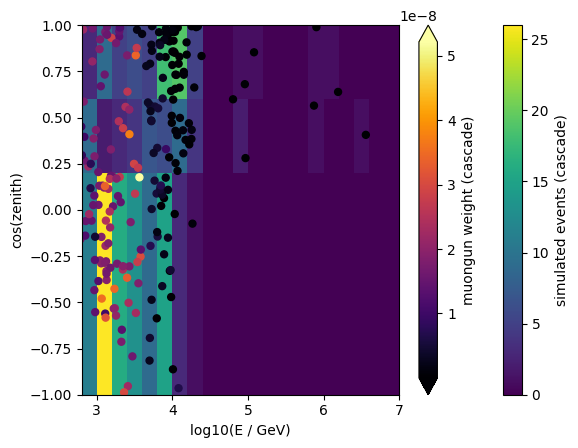

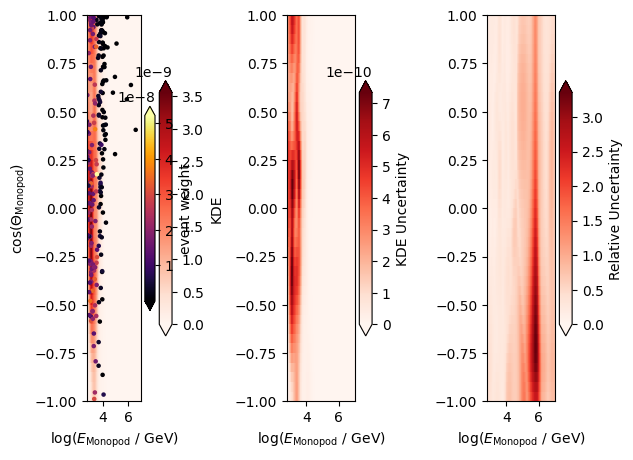

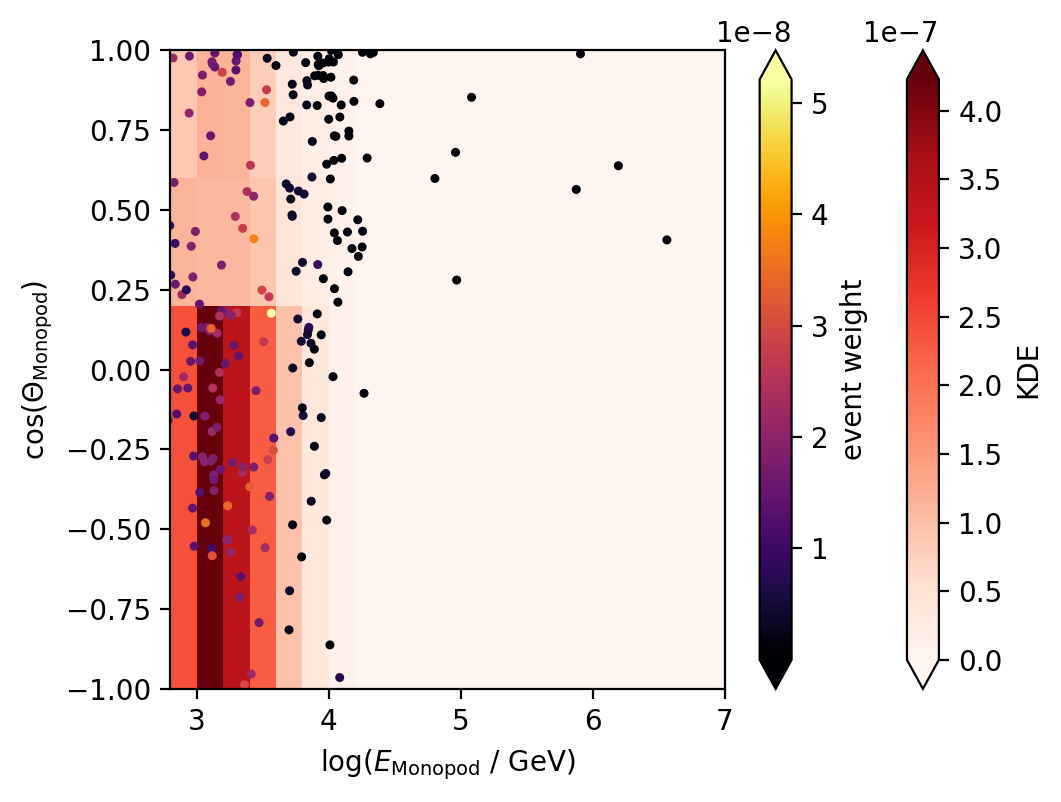

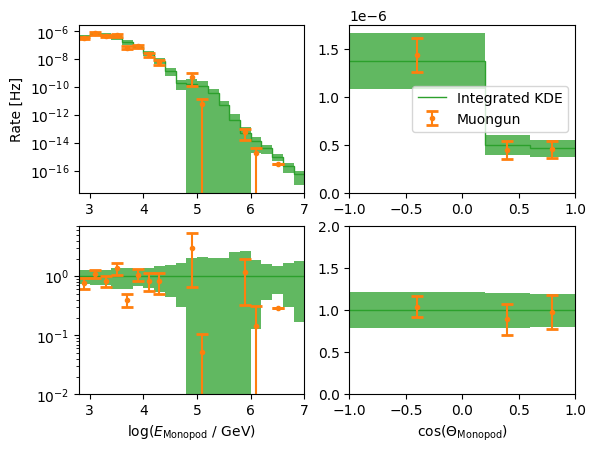

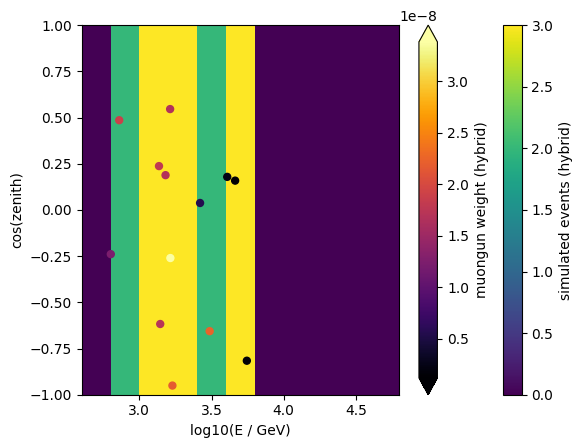

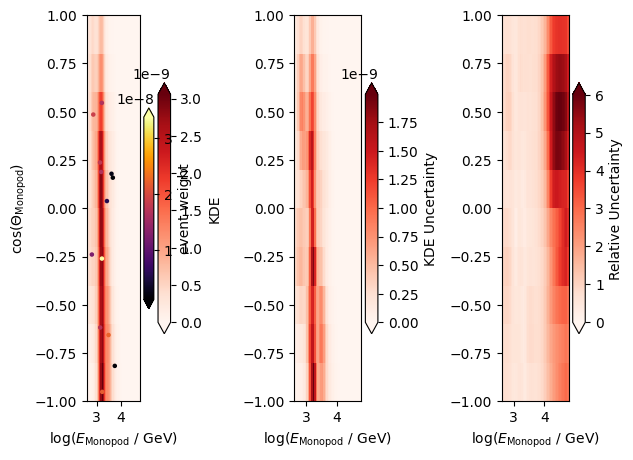

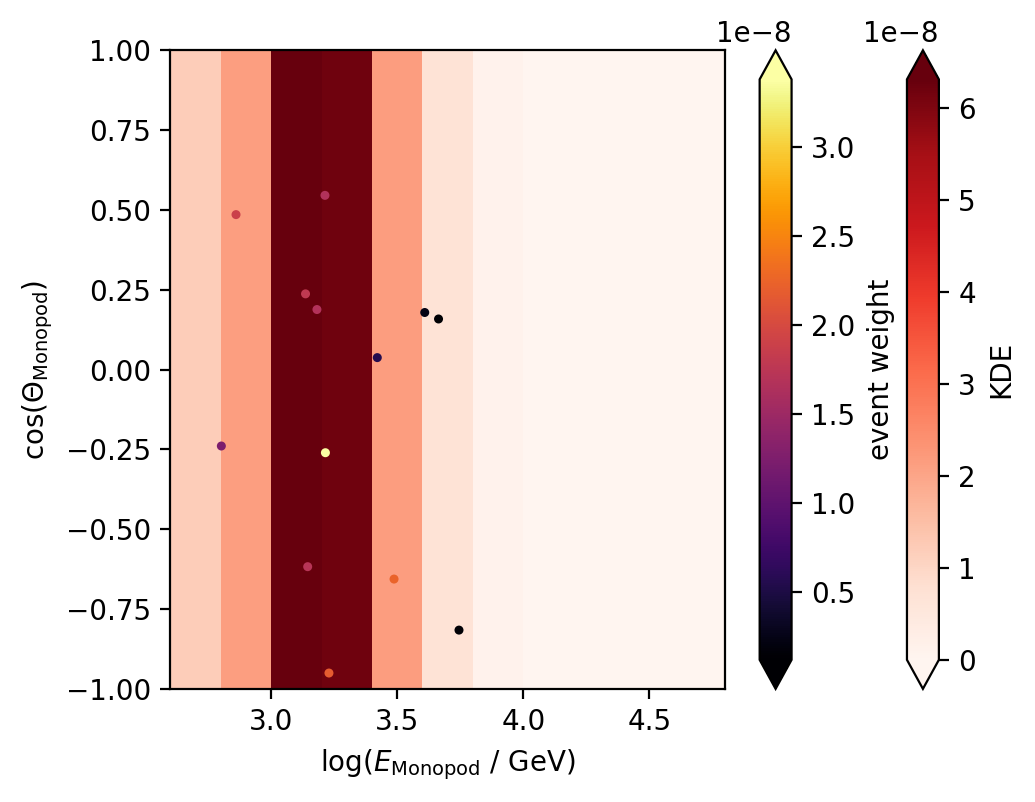

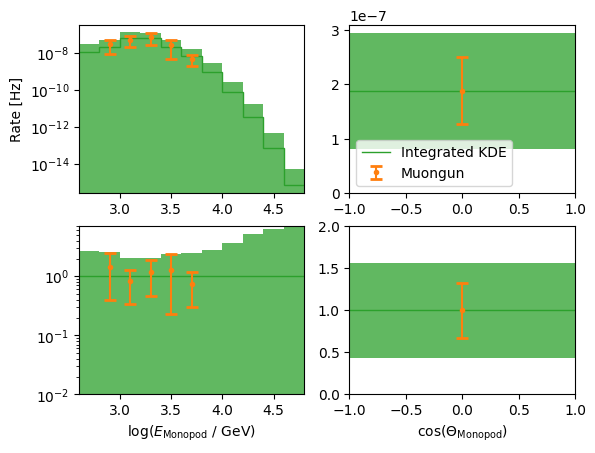

In [35]:
for selection in ["cascade", "hybrid"]:
    # load dataframe
    reco_energy, reco_zenith, weights = get_keys(selection)

    # define all binning variables
    binning = binning_dict[selection]
    bins_e = binning["bins_e"]  # in log(E/GeV)
    bins_cos = binning["bins_cos"]
    bins_e_centers = binning["bins_e_centers"]
    bins_cos_centers = binning["bins_cos_centers"]
    bins_e_fine = binning["bins_e_fine"]
    bins_cos_fine = binning["bins_cos_fine"]
    bins_e_centers_fine = binning["bins_e_centers_fine"]
    bins_cos_centers_fine = binning["bins_cos_centers_fine"]

    # check that fine binning is chosen so that the integration
    # over the coarse bins is correct
    assert all([np.any(np.isclose(v, bins_e_fine)) for v in bins_e])
    assert all([np.any(np.isclose(v, bins_cos_fine)) for v in bins_cos])

    # meshgrid for KDE evaluation
    grid_e, grid_cos = np.meshgrid(bins_e_centers_fine, bins_cos_centers_fine)
    grid_e_cos = np.vstack([grid_e.ravel(), grid_cos.ravel()])

    # just plot a scatterplot of the relevant events
    plot_unweighted(
        selection, bins_e, bins_cos, reco_energy, reco_zenith, weights
    )

    # generate the KDE
    kde = make_kernel(reco_energy, reco_zenith, weights, bins_e, bins_cos)

    # evaluate it on the analysis grid
    X, Y = np.meshgrid(bins_e_centers, bins_cos_centers)
    XYpos = np.vstack([X.ravel(), Y.ravel()])

    kde_evaluated = kde.func_rate_density(XYpos)

    rate = np.reshape(kde_evaluated[0].T, X.shape)
    rate_error = np.reshape(kde_evaluated[1].T, X.shape)

    # evaluate it on the fine grid
    kde_evaluated_fine = kde.func_rate_density(grid_e_cos)
    rate_fine = np.reshape(kde_evaluated_fine[0].T, grid_e.shape)
    rate_error_fine = np.reshape(kde_evaluated_fine[1].T, grid_cos.shape)

    # renorm rate
    rescale_factor = weights.sum() / rate_fine.sum()
    rate_fine *= rescale_factor
    rate_error_fine *= rescale_factor

    # Plot the KDE
    plot_kde_summary(
        selection, reco_energy, reco_zenith, weights, bins_e_fine,
        bins_cos_fine, rate_fine, rate_error_fine
    )

    # integrate the KDE
    integrated_rate, integrated_rate_error = integrate(
        bins_e, bins_cos, bins_e_fine, bins_cos_fine, rate_fine, rate_error_fine
    )

    plot_kde_hist_2D(
        selection, reco_energy, reco_zenith, weights, bins_e, bins_cos,
        integrated_rate
    )

    plot_kde_hist_1D(
        selection, reco_energy, reco_zenith, weights, bins_e, bins_cos,
        integrated_rate, integrated_rate_error
    )

    # save the KDE
    outfile_path = f"/data/user/pfuerst/DiffuseExtensions/templates/muon_background/reproduce_cascade_kde_{selection}_baseline.pickle"

    to_dump = {
        "description":
            f"Muongun KDE for {selection}, normalized to the total rate expected from muongun.",
        "HowToUseInAnalysis":
            "Use as a templateflux component instead of explicit muongun events.",
        "total_rate":
            weights.sum(),
        "template":
            np.fliplr(integrated_rate).flatten(),
        "template_fluctuation":
            np.fliplr(integrated_rate_error).flatten(),

        # binning
        "energy_bins":
            10**bins_e,
        # "energy_bins_centers" : bins_loge_centers,
        "energy_bins_centers_log":
            bins_e_centers,
        "zenith_bins":
            bins_cos,
        "zenith_bins_centers":
            bins_cos_centers,
    }

    import pickle
    with open(outfile_path, "wb") as outfile:
        pickle.dump(to_dump, outfile)

## Muon Histogram

In [36]:
# for the muons, just calculate rate and rate error:
energy, zenith, weights = get_keys("muon")

muon_energy_range = np.array([398.10717055, 63095.73444802])

# mask all events outside energy range:
mask = (energy > muon_energy_range[0]) & (energy < muon_energy_range[1])
energy = energy[mask]
zenith = zenith[mask]
weights = weights[mask]

In [37]:
muon_rate = np.sum(weights)
muon_rate

5.4694021304430105e-05

In [38]:
muon_error = np.sqrt(np.sum(weights**2))
muon_error

1.0954334318777728e-06

## Construct full template

In [39]:
template_cascade = load_pickle(
    "/data/user/pfuerst/DiffuseExtensions/templates/muon_background/reproduce_cascade_kde_cascade_baseline.pickle"
)
template_hybrid = load_pickle(
    "/data/user/pfuerst/DiffuseExtensions/templates/muon_background/reproduce_cascade_kde_hybrid_baseline.pickle"
)

In [40]:
full_template = {
    "IC86_pass2_SnowStorm_v2_cscd_cascade": template_cascade,
    "IC86_pass2_SnowStorm_v2_cscd_hybrid": template_hybrid,
    "IC86_pass2_SnowStorm_v2_cscd_muon":
        {
            'description':
                'Rate and error of muongun events for the single cscd_muon bin',
            'HowToUseInAnalysis':
                'Use as a templateflux component instead of explicit muongun events.',
            'template':
                np.array([muon_rate]),
            'template_fluctuation':
                np.array([muon_error]),
            'energy_bins':
                np.array([398.10717055, 63095.73444802]),
            'energy_bins_centers_log':
                np.array([3.7]),
            'zenith_bins':
                np.array([-1., 1.]),
            'zenith_bins_centers':
                np.array([0.])
        }
}

# dump it
outfile_path = "/data/ana/Diffuse/GlobalFit/NNMFit/templates/cscd_muongun_ALL_KDE_manual_ssq.pickle"
outfile_path_3D = "/data/ana/Diffuse/GlobalFit/NNMFit/templates/cscd_muongun_ALL_KDE_3D_manual_ssq.pickle"
with open(outfile_path, "wb") as outfile:
    pickle.dump(full_template, outfile)

In [41]:
# also save a 3D version of the template
template_3D = full_template.copy()

# keep the 2D template saved:
template_3D["IC86_pass2_SnowStorm_v2_cscd_cascade"][
    "template_2D"] = full_template["IC86_pass2_SnowStorm_v2_cscd_cascade"][
        "template"]

# Update descriptions
n_ra_bins = 18
template_3D["IC86_pass2_SnowStorm_v2_cscd_cascade"][
    "description"] = f"3D casting of template_2D to {n_ra_bins} RA bins"
template_3D["IC86_pass2_SnowStorm_v2_cscd_hybrid"
           ]["description"
            ] = "Still a 2D template, as this det conf has no RA dimension."
template_3D["IC86_pass2_SnowStorm_v2_cscd_muon"
           ]["description"
            ] = "Still a 2D template, as this det conf has no RA dimension."

new_template = np.repeat(
    template_3D["IC86_pass2_SnowStorm_v2_cscd_cascade"]["template"],
    n_ra_bins,
    axis=0
)
new_template /= n_ra_bins

template_3D["IC86_pass2_SnowStorm_v2_cscd_cascade"]["template"] = new_template
template_3D["IC86_pass2_SnowStorm_v2_cscd_cascade"]["ra_bins"] = np.linspace(
    0, 6.28319, n_ra_bins + 1
)

# same for fluctuations:
new_fluctuations = np.repeat(
    template_3D["IC86_pass2_SnowStorm_v2_cscd_cascade"]["template_fluctuation"],
    n_ra_bins,
    axis=0
)
new_fluctuations /= n_ra_bins
template_3D["IC86_pass2_SnowStorm_v2_cscd_cascade"]["template_fluctuation"
                                                   ] = new_fluctuations

# dump the pickle file with the 3D templates:
with open(outfile_path_3D, "wb") as f:
    pickle.dump(template_3D, f)

### compare with the first version (by Erik)

In [42]:
template_reproduce = load_pickle(outfile_path)

# Eriks template with fixed error after discussion with him:
# load KDE
og_all_kde = load_pickle(
    "/data/ana/Diffuse/GlobalFit/NNMFit/templates/cscd_muongun_ALL_KDE.pickle"
)

In [43]:
# check muon normalizations
template_reproduce["IC86_pass2_SnowStorm_v2_cscd_muon"][
    "template"] == og_all_kde["IC86_pass2_SnowStorm_v2_cscd_muon"]["template"]

array([ True])

In [44]:
# this was based on a KDE evaluated for the single bin:
og_all_kde["IC86_pass2_SnowStorm_v2_cscd_muon"]["template_fluctuation"]

array([1.1999744e-12])

In [45]:
template_reproduce["IC86_pass2_SnowStorm_v2_cscd_muon"]["template_fluctuation"]

array([1.09543343e-06])

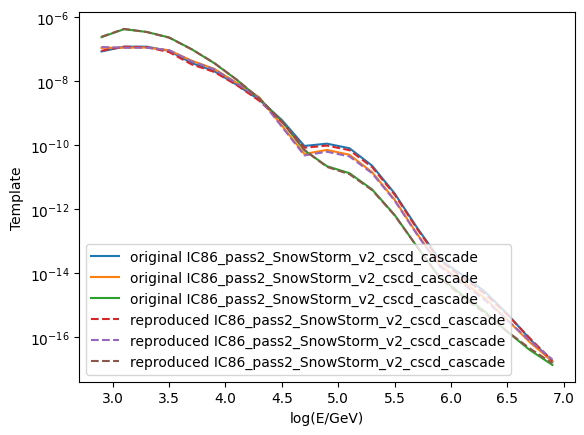

In [46]:
key = "IC86_pass2_SnowStorm_v2_cscd_cascade"
bin_centers_e = template_reproduce[key]["energy_bins_centers_log"]
bin_centers_cos = template_reproduce[key]["zenith_bins_centers"]
reshape_tuple = (len(bin_centers_e), len(bin_centers_cos))

plt.figure()
og_reshaped = np.reshape(og_all_kde[key]["template"], reshape_tuple)
repro_reshaped = np.reshape(template_reproduce[key]["template"], reshape_tuple)

plt.plot(bin_centers_e, og_reshaped, label=f"original {key}")

plt.plot(
    bin_centers_e, repro_reshaped, linestyle="--", label=f"reproduced {key}"
)
plt.yscale("log")
plt.xlabel("log(E/GeV)")
plt.ylabel("Template")
plt.legend()
plt.show()